# 05 - Modelo Base (*Baseline Model*)

### Por: Carlos Javier Palacios Sanchez

### Fecha: 21/08/2026

### Descripción

**Requerimiento.** Crear un modelo base para tenerlo como referencia y luego comparar
al entrenar modelos de *machine learning*. El modelo base puede ser un modelo de
heurísticas o un [modelo *dummy*](https://scikit-learn.org/stable/api/sklearn.dummy.html).
El trabajo se hace en una rama nueva de git siguiendo
[Gitflow](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/)
y sigue los pasos de
[esta guía](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/).

**Proyecto:** Predicción de enfermedad cardíaca (`Heart---Data-Science-Project`)
**Etapa del ciclo de vida:** 5 - Modelos
**Rama:** `5-baseline`
**Datos:** `notebooks/1-data/corazon.csv`
**Etapa previa reutilizada:** `notebooks/4-feat_eng/04_feature_engineering-CJPS-2026-08-20.ipynb`

---

## 0. Qué se hace en este notebook

| # | Punto del requerimiento | Sección |
|---|---|---|
| 1 | Usar el pipeline de procesamiento de la tarea anterior | 2 y 3 |
| 2 | Dividir los datos en *train* / *test* | 4 |
| 3 | Evaluar con diferentes métricas según el problema | 5, 8 y 9 |
| 4 | Validación cruzada con media y desviación estándar | 8 |
| 5 | Seleccionar la variable más importante y justificarla | 6 |
| 6 | Análisis de *learning curve* | 10 |
| 7 | Gráficas de escalabilidad (tiempo de entrenamiento y score) | 11 |
| 8 | Interpretación y análisis de los resultados | 12 y 13 |
| 9 | Conclusiones | 14 |
| 10 | Recomendaciones para construir el modelo | 15 |
| 11 | Propuestas e ideas | 16 |

### Por qué un modelo base

Sin un punto de referencia, cualquier número parece bueno. Un modelo entrenado que
alcanza 80 % de exactitud sobre un problema donde **siempre responder "sano" ya acierta
el 54 %** no ha aprendido tanto como aparenta. El modelo base fija el suelo contra el
cual se mide toda mejora posterior, y —igual de importante— sirve como prueba de que la
tubería completa (datos → preprocesamiento → estimador → evaluación) funciona de extremo
a extremo antes de invertir tiempo en modelos complejos.

En este notebook se comparan **tres familias de modelos base**:

1. **Modelos *dummy*** (`DummyClassifier`): ignoran por completo los atributos. Definen
   el piso absoluto.
2. **Regla de una sola variable**: un *tocón de decisión* (`max_depth=1`) sobre el
   atributo más informativo. Mide cuánto se consigue con **un solo dato del paciente**.
3. **Heurística clínica**: una regla de conteo de factores de riesgo, escrita a mano,
   **sin aprender ningún parámetro** de los datos. Representa "lo que haría un médico
   con una lista de chequeo".

Se incluye además una **regresión logística** como referencia superior. No es un modelo
base: sirve para saber cuánto margen queda entre la heurística y un modelo aprendido
sencillo.

## 1. Configuración e importación de librerías

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

SEMILLA = 42
PROPORCION_TEST = 0.2

print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")

pandas       3.0.5
numpy        2.4.6
scikit-learn 1.9.0


### Rutas del proyecto

Se resuelve la raíz del repositorio buscando `pyproject.toml` hacia arriba, para que el
notebook funcione igual si se ejecuta desde su carpeta o desde la raíz del proyecto.

In [2]:
RUTA_RAIZ = Path.cwd().resolve()
while not (RUTA_RAIZ / "pyproject.toml").exists() and RUTA_RAIZ.parent != RUTA_RAIZ:
    RUTA_RAIZ = RUTA_RAIZ.parent

RUTA_CRUDOS = RUTA_RAIZ / "notebooks" / "1-data" / "corazon.csv"
RUTA_MODELOS = RUTA_RAIZ / "models"
RUTA_REPORTES = RUTA_RAIZ / "data" / "08_reporting"

for carpeta in (RUTA_MODELOS, RUTA_REPORTES):
    carpeta.mkdir(parents=True, exist_ok=True)

# `src` contiene el pipeline de la etapa 4 empaquetado como módulo importable.
if str(RUTA_RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RUTA_RAIZ / "src"))

print(f"Raíz del proyecto : {RUTA_RAIZ}")
print(f"Datos crudos      : {RUTA_CRUDOS.relative_to(RUTA_RAIZ)}")

Raíz del proyecto : /home/claude/repo
Datos crudos      : notebooks/1-data/corazon.csv


## 2. Reutilización del pipeline de la etapa anterior

En la etapa 4 el pipeline de preparación vivía **dentro del notebook**. Eso lo hacía
imposible de reutilizar: el artefacto serializado (`models/pipeline_feature_engineering.joblib`)
no se puede deserializar sin volver a ejecutar las celdas que definen los
transformadores personalizados, y copiar y pegar el código a este notebook habría creado
dos versiones del mismo pipeline que se desincronizan a la primera corrección.

Por eso, como parte de esta tarea, el pipeline se consolidó en un módulo importable:

```
src/pipelines/feature_pipeline/
├── __init__.py
└── feature_pipeline.py     # contratos de datos + limpieza + transformadores + fábrica
```

El código es **el mismo** de la etapa 4 (se verifica más abajo que reproduce el dataset
limpio byte a byte); lo que cambia es dónde vive. Ahora este notebook, la etapa de
entrenamiento y el servicio de inferencia consumen exactamente la misma definición, y
`tests/pipelines/feature_pipeline/` la prueba en cada *push* dentro del CI.

In [3]:
from pipelines.feature_pipeline import (
    ATRIBUTOS_DERIVADOS,
    OBJETIVO,
    construir_pipeline_features,
    limpiar_datos,
)

# Atributos que sobrevivieron a la selección de la etapa 4: se descartó `fbs`
# (información mutua ~ 0 con el target).
ATRIBUTOS_SELECCIONADOS = [
    "age",
    "sex",
    "chest_pain",
    "rest_bp",
    "chol",
    "rest_ecg",
    "max_hr",
    "exang",
    "old_peak",
    "slope",
    "ca",
    "thal",
]

print(f"Atributos de entrada   ({len(ATRIBUTOS_SELECCIONADOS)}): {ATRIBUTOS_SELECCIONADOS}")
print(f"Atributos derivados    ({len(ATRIBUTOS_DERIVADOS)}): {ATRIBUTOS_DERIVADOS}")

pipeline_features = construir_pipeline_features(ATRIBUTOS_SELECCIONADOS)
pipeline_features

Atributos de entrada   (12): ['age', 'sex', 'chest_pain', 'rest_bp', 'chol', 'rest_ecg', 'max_hr', 'exang', 'old_peak', 'slope', 'ca', 'thal']
Atributos derivados    (7): ['fc_maxima_teorica', 'reserva_cardiaca', 'chol_rel_edad', 'carga_presion', 'log_old_peak', 'sqrt_chol', 'st_deprimido']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('atributos_derivados', ...), ('preprocesamiento', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function agr...x7f99cfd8e160>
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function nom...x7f99cfd8eb60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"kw

> **Nota metodológica.** `construir_pipeline_features()` devuelve el pipeline **sin
> ajustar**. Es lo que se necesita aquí: en validación cruzada el preprocesamiento debe
> re-ajustarse dentro de cada *fold*, usando sólo los datos de entrenamiento de ese
> *fold*. Reutilizar el `.joblib` ya ajustado sobre todo el conjunto de entrenamiento
> filtraría información de los *folds* de validación e inflaría artificialmente los
> resultados.

## 3. Carga y limpieza de los datos

La limpieza (`limpiar_datos`) es idéntica a la de la etapa 4: normaliza el texto,
invalida los valores fuera de dominio, elimina los registros sin *target*, las filas con
más del 50 % de celdas vacías y los duplicados —exactos y parciales—. Al no aprender
ningún parámetro de los datos, puede aplicarse antes de la partición sin producir fuga.

In [4]:
datos_crudos = pd.read_csv(RUTA_CRUDOS, dtype=str, keep_default_na=True)
datos_limpios = limpiar_datos(datos_crudos)

print(f"Crudos  : {datos_crudos.shape[0]:>5,} filas x {datos_crudos.shape[1]} columnas")
print(f"Limpios : {datos_limpios.shape[0]:>5,} filas x {datos_limpios.shape[1]} columnas")
print(f"Reducción: {1 - len(datos_limpios) / len(datos_crudos):.1%} de los registros crudos\n")

distribucion = datos_limpios[OBJETIVO].value_counts().sort_index()
proporcion = datos_limpios[OBJETIVO].value_counts(normalize=True).sort_index()
print("Distribución del target (0 = sano, 1 = enfermedad):")
for clase in distribucion.index:
    print(f"  {clase} -> {distribucion[clase]:>3} pacientes ({proporcion[clase]:.1%})")

datos_limpios.head()

Crudos  : 3,030 filas x 14 columnas
Limpios :   303 filas x 14 columnas
Reducción: 90.0% de los registros crudos

Distribución del target (0 = sano, 1 = enfermedad):
  0 -> 164 pacientes (54.1%)
  1 -> 139 pacientes (45.9%)


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63.0,Male,typical,145.0,233.0,1.0,left ventricular hypertrophy,150.0,0.0,2.3,3.0,0.0,fixed,0
1,67.0,Male,asymptomatic,160.0,286.0,0.0,left ventricular hypertrophy,108.0,1.0,1.5,2.0,3.0,normal,1
2,67.0,Male,asymptomatic,120.0,229.0,0.0,left ventricular hypertrophy,129.0,1.0,2.6,2.0,2.0,reversable,1
3,37.0,Male,nonanginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,3.0,0.0,normal,0
4,41.0,Female,nontypical,130.0,204.0,0.0,left ventricular hypertrophy,172.0,0.0,1.4,1.0,0.0,normal,0


El conjunto está **casi balanceado** (46 % de pacientes enfermos). Esto tiene una
consecuencia directa sobre el modelo base: la estrategia trivial de "predecir siempre la
clase mayoritaria" acierta alrededor del **54 %** de las veces. Ése, y no el 50 % que uno
esperaría por intuición, es el número que hay que superar.

## 4. División *train* / *test*

Se usa la **misma partición de la etapa 4**: 80 / 20, estratificada por el *target* y con
`random_state=42`. Mantener la semilla y la proporción no es un detalle cosmético: permite
comparar directamente los resultados de este modelo base con los de las etapas anterior y
siguientes sin que la diferencia se explique por un reparto distinto de los pacientes.

El conjunto de *test* se aparta aquí y **no se vuelve a tocar** hasta la sección 9.
Todas las decisiones (elección de la variable más importante, comparación de modelos base)
se toman exclusivamente con validación cruzada sobre *train*.

In [5]:
X = datos_limpios[ATRIBUTOS_SELECCIONADOS]
y = datos_limpios[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, stratify=y, random_state=SEMILLA
)

resumen_particion = pd.DataFrame(
    {
        "n_pacientes": [len(y_train), len(y_test), len(y)],
        "n_enfermos": [int(y_train.sum()), int(y_test.sum()), int(y.sum())],
        "prevalencia": [y_train.mean(), y_test.mean(), y.mean()],
    },
    index=["train", "test", "total"],
)
resumen_particion["prevalencia"] = resumen_particion["prevalencia"].round(4)
resumen_particion

,n_pacientes,n_enfermos,prevalencia
train,242,111,0.4587
test,61,28,0.4590
total,303,139,0.4587


## 5. Métricas de evaluación: cuáles y por qué

El problema es una **clasificación binaria con costo asimétrico**. No es lo mismo
equivocarse en un sentido que en el otro:

- Un **falso negativo** es un paciente con enfermedad coronaria al que el sistema
  clasifica como sano y se envía a casa sin estudio adicional. El costo potencial es un
  evento cardíaco no prevenido.
- Un **falso positivo** es un paciente sano derivado a una prueba confirmatoria. El costo
  es económico y de ansiedad, pero acotado y reversible.

Por eso **una sola métrica no basta**, y en particular la exactitud sola es engañosa.
Estas son las métricas que se reportan y qué pregunta responde cada una:

| Métrica | Pregunta que responde | Por qué se incluye aquí |
|---|---|---|
| **Exactitud** (*accuracy*) | ¿Qué fracción de pacientes clasifica bien? | Es la referencia intuitiva, pero con 46 % de positivos premia al modelo trivial. Se reporta para mostrar precisamente ese sesgo. |
| **Exactitud balanceada** | Promedio de aciertos en cada clase por separado | Neutraliza el desbalance: cualquier modelo constante vale exactamente 0.50, sin importar la prevalencia. |
| **Precisión** | De los que marco como enfermos, ¿cuántos lo están? | Mide el desperdicio de pruebas confirmatorias. |
| **Sensibilidad** (*recall*) | De los enfermos reales, ¿cuántos detecto? | **La métrica clínica crítica**: su complemento son los falsos negativos. |
| **Especificidad** | De los sanos reales, ¿cuántos descarto bien? | Complemento de la sensibilidad; juntas describen el compromiso completo. |
| **F1** | Media armónica de precisión y sensibilidad | Resumen equilibrado de las dos anteriores. |
| **F2** | Igual que F1 pero pesando la sensibilidad ×2 | Refleja explícitamente el costo asimétrico del tamizaje clínico. |
| **ROC-AUC** | ¿Ordena bien a los pacientes por riesgo? | **Independiente del umbral de decisión**: mide la calidad del *ranking*, no de un corte particular. Es la métrica principal para comparar modelos. |
| **PR-AUC** | Lo mismo, centrado en la clase positiva | Más informativa que ROC-AUC si la prevalencia bajara (p. ej. en tamizaje poblacional). |
| **MCC** | Correlación entre predicción y realidad usando las cuatro celdas de la matriz | Es la más difícil de "engañar": vale 0 para cualquier modelo trivial, incluso los aleatorios. |
| ***Brier score*** | ¿Están calibradas las probabilidades? | Un modelo de riesgo clínico debe dar una probabilidad creíble, no sólo una etiqueta. |

**Métrica de decisión adoptada: ROC-AUC**, con la sensibilidad y el MCC como criterios de
desempate. La razón es que el modelo final se usará como herramienta de priorización, y lo
que importa es el orden de riesgo entre pacientes; el umbral se puede ajustar después
según la capacidad del servicio.

In [6]:
def especificidad(y_verdadero, y_predicho) -> float:
    """Proporción de pacientes sanos correctamente identificados como sanos."""
    return recall_score(y_verdadero, y_predicho, pos_label=0, zero_division=0)


METRICAS = {
    "exactitud": make_scorer(accuracy_score),
    "exactitud_balanceada": make_scorer(balanced_accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "sensibilidad": make_scorer(recall_score, zero_division=0),
    "especificidad": make_scorer(especificidad),
    "f1": make_scorer(fbeta_score, beta=1, zero_division=0),
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
    "pr_auc": make_scorer(average_precision_score, response_method="predict_proba"),
    "mcc": make_scorer(matthews_corrcoef),
    "brier": make_scorer(
        brier_score_loss, response_method="predict_proba", greater_is_better=False
    ),
}

# Estrategia de validación cruzada: 5 particiones estratificadas repetidas 6 veces con
# semillas distintas = 30 evaluaciones. Con sólo 242 pacientes de entrenamiento, una
# única pasada de 5 folds da desviaciones estándar demasiado inestables para comparar
# modelos que difieren en pocos puntos.
VALIDACION = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=SEMILLA)

print(f"Métricas evaluadas : {len(METRICAS)}")
print(f"Evaluaciones por modelo: {VALIDACION.get_n_splits()} (5 folds x 6 repeticiones)")

Métricas evaluadas : 11
Evaluaciones por modelo: 30 (5 folds x 6 repeticiones)


## 6. ¿Cuál es la variable más importante?

El requerimiento pide seleccionar **una** variable y justificar la elección. Un único
criterio puede engañar, así que se triangula con dos métodos independientes, ambos
calculados **sólo sobre `train`**:

1. **Información mutua** con el *target* (`mutual_info_classif`): mide la dependencia
   estadística —lineal o no— entre el atributo y el diagnóstico, en nats. Es el mismo
   criterio que se usó en la selección de atributos de la etapa 4, promediado sobre 15
   semillas porque el estimador es estocástico.
2. **ROC-AUC de un modelo de una sola variable**: se entrena un *tocón de decisión*
   (`DecisionTreeClassifier(max_depth=1)`) usando únicamente ese atributo y se mide su
   ROC-AUC en validación cruzada. Responde a la pregunta operativa directa: *si sólo
   pudiera preguntarle un dato al paciente, ¿qué tan bien podría ordenarlo por riesgo?*

El segundo criterio es el que decide, porque se expresa en la misma unidad con la que se
compararán los modelos y trae su propia desviación estándar.

In [7]:
def preprocesador_univariado(columna: str, datos: pd.DataFrame):
    """Preprocesamiento mínimo para evaluar un atributo aislado."""
    if pd.api.types.is_numeric_dtype(datos[columna]):
        return SimpleImputer(strategy="median")
    return Pipeline(
        steps=[
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            ("codificacion", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )


def modelo_una_variable(columna: str, datos: pd.DataFrame) -> Pipeline:
    """Tocón de decisión (`max_depth=1`) que usa un único atributo."""
    return Pipeline(
        steps=[
            ("features", preprocesador_univariado(columna, datos)),
            ("modelo", DecisionTreeClassifier(max_depth=1, random_state=SEMILLA)),
        ]
    )


registros = []
for columna in ATRIBUTOS_SELECCIONADOS:
    puntajes = cross_validate(
        modelo_una_variable(columna, X_train),
        X_train[[columna]],
        y_train,
        cv=VALIDACION,
        scoring="roc_auc",
    )["test_score"]
    registros.append((columna, puntajes.mean(), puntajes.std()))

importancia = pd.DataFrame(registros, columns=["atributo", "auc_univariado", "auc_std"])
importancia = importancia.set_index("atributo")

In [8]:
# Información mutua: se imputa y se codifica de forma simple sólo para este diagnóstico.
X_train_codificado = X_train.copy()
for columna in X_train_codificado.columns:
    serie = X_train_codificado[columna]
    if pd.api.types.is_numeric_dtype(serie):
        X_train_codificado[columna] = serie.fillna(serie.median())
    else:
        X_train_codificado[columna] = (
            serie.fillna(serie.mode(dropna=True).iloc[0]).astype("category").cat.codes
        )

atributos_discretos = [X_train_codificado[c].nunique() <= 5 for c in X_train_codificado.columns]  # noqa: PLR2004
info_mutua = pd.Series(
    np.mean(
        [
            mutual_info_classif(
                X_train_codificado,
                y_train,
                discrete_features=atributos_discretos,
                random_state=semilla,
            )
            for semilla in range(15)
        ],
        axis=0,
    ),
    index=X_train_codificado.columns,
)

importancia["info_mutua"] = info_mutua
importancia["rango_auc"] = importancia["auc_univariado"].rank(ascending=False).astype(int)
importancia["rango_im"] = importancia["info_mutua"].rank(ascending=False).astype(int)
importancia = importancia.sort_values("auc_univariado", ascending=False)
importancia.round(4)

,auc_univariado,auc_std,info_mutua,rango_auc,rango_im
atributo,,,,,
thal,0.7647,0.0607,0.1560,1,1
chest_pain,0.7439,0.0564,0.1272,2,2
ca,0.7236,0.0620,0.1161,3,3
exang,0.6975,0.0572,0.0911,4,4
slope,0.6844,0.0486,0.0706,5,7
max_hr,0.6752,0.0625,0.0833,6,5
sex,0.6441,0.0505,0.0496,7,9
old_peak,0.6358,0.0423,0.0778,8,6
age,0.6145,0.0660,0.0035,9,12


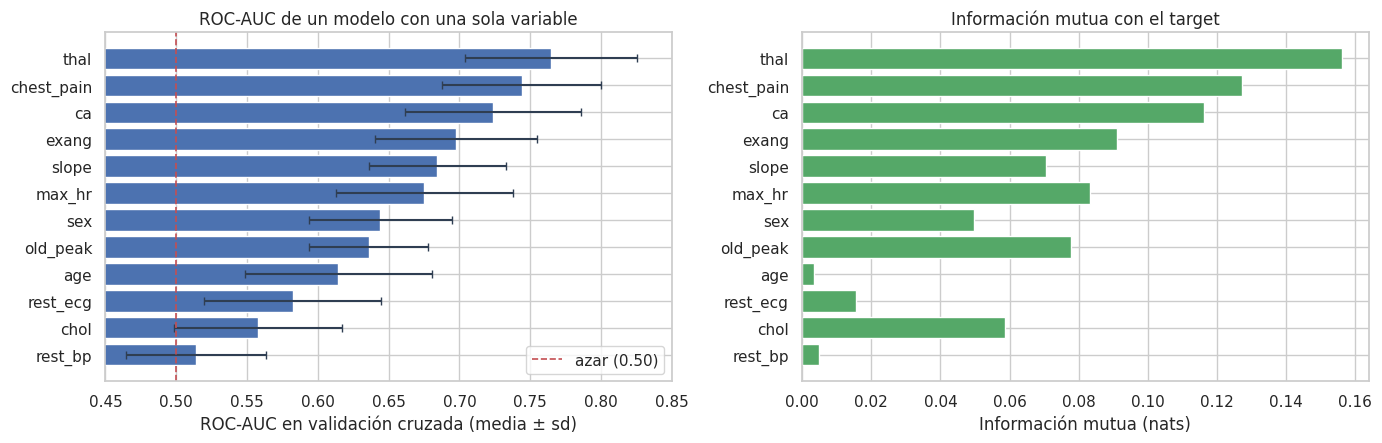

Variable más importante: 'thal'
  ROC-AUC univariado : 0.7647 ± 0.0607
  Información mutua  : 0.1560


In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))

orden = importancia.index.to_numpy()
ejes[0].barh(orden, importancia["auc_univariado"].to_numpy(), color="#4C72B0")
ejes[0].errorbar(
    importancia["auc_univariado"].to_numpy(),
    orden,
    xerr=importancia["auc_std"].to_numpy(),
    fmt="none",
    ecolor="#2F3E52",
    capsize=3,
)
ejes[0].axvline(0.5, color="#C44E52", linestyle="--", linewidth=1.2, label="azar (0.50)")
ejes[0].set_xlim(0.45, 0.85)
ejes[0].invert_yaxis()
ejes[0].set_title("ROC-AUC de un modelo con una sola variable")
ejes[0].set_xlabel("ROC-AUC en validación cruzada (media ± sd)")
ejes[0].legend(loc="lower right")

ejes[1].barh(orden, importancia["info_mutua"].to_numpy(), color="#55A868")
ejes[1].invert_yaxis()
ejes[1].set_title("Información mutua con el target")
ejes[1].set_xlabel("Información mutua (nats)")

plt.tight_layout()
plt.show()

VARIABLE_MAS_IMPORTANTE = importancia.index[0]
print(f"Variable más importante: '{VARIABLE_MAS_IMPORTANTE}'")
print(
    f"  ROC-AUC univariado : {importancia.loc[VARIABLE_MAS_IMPORTANTE, 'auc_univariado']:.4f}"
    f" ± {importancia.loc[VARIABLE_MAS_IMPORTANTE, 'auc_std']:.4f}"
)
print(f"  Información mutua  : {importancia.loc[VARIABLE_MAS_IMPORTANTE, 'info_mutua']:.4f}")

### Justificación de la variable seleccionada: `thal`

`thal` (resultado de la **gammagrafía de perfusión miocárdica con talio**: `normal`,
`fixed` = defecto fijo, `reversable` = defecto reversible) queda en **primer lugar en los
dos criterios simultáneamente**:

- **ROC-AUC univariado 0.765 ± 0.061**, el más alto de los doce atributos. Es decir: con
  sólo mirar el resultado del talio, un modelo ordena correctamente a un par
  enfermo/sano el 76.5 % de las veces, frente al 50 % del azar.
- **Información mutua 0.156 nats**, también la más alta, y un 23 % por encima del segundo
  atributo (`chest_pain`, 0.127).

Que **ambos métodos coincidan** es lo que da confianza en la elección: la información
mutua detecta cualquier forma de dependencia pero no dice si es explotable por un modelo;
el AUC univariado sí lo dice, pero depende del estimador. Coincidiendo los dos, la señal
es real y aprovechable.

La justificación clínica refuerza la estadística y es la parte que importa para defender
el modelo ante un médico: `thal` no es un factor de riesgo indirecto como la edad o el
colesterol, sino una **medición directa de la perfusión del músculo cardíaco**. Un defecto
reversible en la gammagrafía es evidencia de isquemia inducible —exactamente el fenómeno
que la variable objetivo intenta capturar—. Los demás atributos son *proxies*: describen
condiciones que aumentan la probabilidad de enfermedad; `thal` observa una consecuencia
de la enfermedad misma.

**Dos advertencias que conviene registrar ahora**, porque condicionan la lectura de todo
lo que sigue:

1. `thal` es una prueba de imagen **costosa y no disponible en atención primaria**. Un
   modelo que dependa de ella no sirve para tamizaje inicial. En la sección 16 se propone
   evaluar un modelo restringido a variables de consultorio.
2. Su poder predictivo tan alto sugiere que la gammagrafía pudo formar parte del proceso
   diagnóstico que generó la etiqueta `disease`. Si así fuera, existiría **fuga de
   información clínica** (no estadística): el atributo conocería parte de la respuesta.
   Es una hipótesis que debe verificarse con quien conozca el protocolo de recolección.

Los tres primeros atributos —`thal` (0.765), `chest_pain` (0.744) y `ca` (0.724)— están
tan cerca entre sí que la elección no es robusta a la partición: con otra semilla el orden
podría cambiar. Se documenta como una elección justificada, no como un hecho establecido.
Al otro extremo, `rest_bp` (0.514) y `chol` (0.558) son **prácticamente indistinguibles
del azar por sí solos**, un resultado contraintuitivo dado su peso en el discurso clínico
habitual.

## 7. Los modelos base candidatos

### 7.1 Modelos *dummy*

`DummyClassifier` **ignora por completo los atributos**: sólo mira la distribución del
*target*. Se evalúan cinco estrategias porque cada una fija un piso distinto:

| Estrategia | Qué hace | Qué piso establece |
|---|---|---|
| `most_frequent` | Siempre predice la clase mayoritaria (sano) | El piso de exactitud que hay que superar |
| `prior` | Igual, pero sus probabilidades son la prevalencia | Piso del *Brier score* |
| `stratified` | Predice al azar respetando la proporción de clases | Piso de un modelo "aleatorio informado" |
| `uniform` | Predice al azar 50/50 | Piso de un modelo sin ninguna información |
| `constant=1` | Declara enfermos a todos los pacientes | El extremo opuesto: sensibilidad 100 % a costa de todo lo demás |

### 7.2 Regla de una sola variable

Un tocón de decisión sobre `thal`. Es el eslabón entre los *dummy* y los modelos reales:
mide **cuánto del desempeño se explica por el atributo más informativo**, y por lo tanto
cuánto valor añade el resto del pipeline.

### 7.3 Heurística clínica

Una regla escrita a mano que **no aprende nada de los datos**: cuenta cuántos de cuatro
factores de riesgo presenta el paciente y usa esa proporción como probabilidad. Los cuatro
factores se eligieron por criterio clínico, no por su desempeño en este dataset:

| Señal | Fundamento clínico |
|---|---|
| `chest_pain == "asymptomatic"` | La enfermedad coronaria silente es frecuente y de peor pronóstico |
| `exang == 1` | Angina inducida por ejercicio: isquemia demostrada bajo esfuerzo |
| `old_peak > 1.0` | Depresión del segmento ST > 1 mm es el criterio electrocardiográfico clásico de isquemia |
| `ca > 0` | Al menos un vaso principal con estrechamiento visible en fluoroscopía |

Con umbral de 2 señales sobre 4 se emite el diagnóstico positivo. Este modelo es
**auditable, explicable a un clínico y desplegable sin infraestructura**, lo que lo
convierte en el competidor honesto contra el cual cualquier modelo de *machine learning*
debe justificar su complejidad.

In [10]:
class ReglaClinica(ClassifierMixin, BaseEstimator):
    """Heurística clínica: cuenta señales de riesgo. No aprende ningún parámetro.

    La probabilidad predicha es la fracción de señales presentes (0, 0.25, ..., 1.0), lo
    que permite calcular ROC-AUC y Brier score igual que con cualquier otro clasificador.
    """

    def __init__(self, umbral: int = 2) -> None:
        self.umbral = umbral

    def _puntaje(self, X: pd.DataFrame) -> pd.Series:
        """Número de señales de riesgo presentes (0 a 4). Los faltantes cuentan como ausencia."""
        senales = pd.Series(0.0, index=X.index)
        senales += (X["chest_pain"] == "asymptomatic").astype(float)
        senales += (X["exang"] == 1).astype(float)
        senales += (X["old_peak"] > 1.0).astype(float)
        senales += (X["ca"].fillna(0) > 0).astype(float)
        return senales

    def fit(self, X: pd.DataFrame, y=None) -> "ReglaClinica":
        """No hay nada que ajustar; sólo se registran los metadatos que exige scikit-learn."""
        del y
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Probabilidad de enfermedad = fracción de señales de riesgo presentes."""
        probabilidad = (self._puntaje(X) / 4.0).to_numpy()
        return np.column_stack([1.0 - probabilidad, probabilidad])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Diagnóstico positivo si el paciente acumula al menos `umbral` señales."""
        return (self._puntaje(X).to_numpy() >= self.umbral).astype(int)


class ReglaUnaVariable(ClassifierMixin, BaseEstimator):
    """Modelo base que usa un único atributo mediante un tocón de decisión."""

    def __init__(self, columna: str = "thal") -> None:
        self.columna = columna

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "ReglaUnaVariable":
        """Aprende el corte óptimo sobre la única columna seleccionada."""
        self.pipeline_ = modelo_una_variable(self.columna, X).fit(X[[self.columna]], y)
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Probabilidades del tocón ajustado."""
        return self.pipeline_.predict_proba(X[[self.columna]])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Etiquetas del tocón ajustado."""
        return self.pipeline_.predict(X[[self.columna]])

In [11]:
def con_preprocesamiento(estimador) -> Pipeline:
    """Encadena el pipeline de la etapa 4 con un estimador."""
    return Pipeline(
        steps=[
            ("features", construir_pipeline_features(ATRIBUTOS_SELECCIONADOS)),
            ("modelo", estimador),
        ]
    )


MODELOS = {
    "dummy_mayoritaria": con_preprocesamiento(DummyClassifier(strategy="most_frequent")),
    "dummy_prior": con_preprocesamiento(DummyClassifier(strategy="prior")),
    "dummy_estratificado": con_preprocesamiento(
        DummyClassifier(strategy="stratified", random_state=SEMILLA)
    ),
    "dummy_uniforme": con_preprocesamiento(
        DummyClassifier(strategy="uniform", random_state=SEMILLA)
    ),
    "dummy_todos_enfermos": con_preprocesamiento(DummyClassifier(strategy="constant", constant=1)),
    f"regla_1var({VARIABLE_MAS_IMPORTANTE})": ReglaUnaVariable(VARIABLE_MAS_IMPORTANTE),
    "heuristica_clinica": ReglaClinica(umbral=2),
    "referencia_reg_logistica": con_preprocesamiento(
        LogisticRegression(max_iter=2000, random_state=SEMILLA)
    ),
}

MODELOS_BASE = [nombre for nombre in MODELOS if not nombre.startswith("referencia_")]

for nombre in MODELOS:
    marca = "referencia" if nombre.startswith("referencia_") else "modelo base"
    print(f"  {nombre:<28} [{marca}]")

  dummy_mayoritaria            [modelo base]
  dummy_prior                  [modelo base]
  dummy_estratificado          [modelo base]
  dummy_uniforme               [modelo base]
  dummy_todos_enfermos         [modelo base]
  regla_1var(thal)             [modelo base]
  heuristica_clinica           [modelo base]
  referencia_reg_logistica     [referencia]


## 8. Validación cruzada

Cada modelo se evalúa con **`RepeatedStratifiedKFold(5 × 6) = 30 particiones**. La
repetición con semillas distintas es necesaria aquí: con 242 pacientes de entrenamiento,
cada *fold* de validación tiene unos 48 casos, y una sola pasada de 5 *folds* produce
desviaciones estándar tan ruidosas que dos modelos separados por 3 puntos parecerían
indistinguibles.

Todo el preprocesamiento va **dentro** del pipeline que se pasa a `cross_validate`, de
modo que la imputación, los límites de atípicos y el escalado se re-aprenden en cada
*fold* usando exclusivamente su porción de entrenamiento.

Se reportan la **media** y la **desviación estándar** de cada métrica, tal como pide el
requerimiento.

In [12]:
resultados_cv = {}
tiempos_cv = {}

for nombre, estimador in MODELOS.items():
    salida = cross_validate(
        estimador,
        X_train,
        y_train,
        cv=VALIDACION,
        scoring=METRICAS,
        n_jobs=-1,
        return_train_score=False,
    )
    resultados_cv[nombre] = {metrica: salida[f"test_{metrica}"] for metrica in METRICAS}
    tiempos_cv[nombre] = (salida["fit_time"].mean(), salida["score_time"].mean())

medias = pd.DataFrame({n: {m: v.mean() for m, v in d.items()} for n, d in resultados_cv.items()}).T
desviaciones = pd.DataFrame(
    {n: {m: v.std() for m, v in d.items()} for n, d in resultados_cv.items()}
).T

# El Brier score se calcula como negativo (convención de scikit-learn: más alto = mejor).
medias["brier"] = -medias["brier"]

print("MEDIA de las 30 evaluaciones de validación cruzada")
medias.round(4)

MEDIA de las 30 evaluaciones de validación cruzada


,exactitud,exactitud_balanceada,precision,sensibilidad,especificidad,f1,f2,roc_auc,pr_auc,mcc,brier
dummy_mayoritaria,0.5413,0.5000,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.4587,0.0000,0.4587
dummy_prior,0.5413,0.5000,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.4587,0.0000,0.2483
dummy_estratificado,0.5139,0.5039,0.4640,0.3842,0.6237,0.4203,0.3979,0.5039,0.4660,0.0082,0.4861
dummy_uniforme,0.5096,0.5118,0.4698,0.5375,0.4860,0.5013,0.5224,0.5000,0.4587,0.0235,0.2500
dummy_todos_enfermos,0.4587,0.5000,0.4587,1.0000,0.0000,0.6289,0.8090,0.5000,0.4587,0.0000,0.5413
regla_1var(thal),0.7685,0.7647,0.7671,0.7189,0.8104,0.7391,0.7262,0.7647,0.6831,0.5358,0.1802
heuristica_clinica,0.7810,0.7804,0.7550,0.7746,0.7863,0.7630,0.7695,0.8482,0.8148,0.5619,0.1555
referencia_reg_logistica,0.8043,0.7995,0.8208,0.7427,0.8563,0.7761,0.7550,0.8833,0.8800,0.6092,0.1394


In [13]:
print("DESVIACIÓN ESTÁNDAR de las 30 evaluaciones")
desviaciones.round(4)

DESVIACIÓN ESTÁNDAR de las 30 evaluaciones


,exactitud,exactitud_balanceada,precision,sensibilidad,especificidad,f1,f2,roc_auc,pr_auc,mcc,brier
dummy_mayoritaria,0.0065,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0065,0.0000,0.0065
dummy_prior,0.0065,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0065,0.0000,0.0005
dummy_estratificado,0.0609,0.0615,0.0822,0.0661,0.0576,0.0732,0.0687,0.0615,0.0323,0.1263,0.0609
dummy_uniforme,0.0744,0.0749,0.0712,0.0810,0.0691,0.0757,0.0787,0.0000,0.0065,0.1494,0.0000
dummy_todos_enfermos,0.0065,0.0000,0.0065,0.0000,0.0000,0.0061,0.0040,0.0000,0.0065,0.0000,0.0065
regla_1var(thal),0.0602,0.0607,0.0808,0.0889,0.0763,0.0717,0.0800,0.0607,0.0699,0.1225,0.0336
heuristica_clinica,0.0607,0.0621,0.0651,0.0898,0.0606,0.0691,0.0800,0.0553,0.0545,0.1238,0.0295
referencia_reg_logistica,0.0615,0.0617,0.0881,0.0859,0.0831,0.0716,0.0782,0.0447,0.0489,0.1241,0.0321


In [14]:
# Tabla combinada "media ± sd", que es la forma en que conviene reportar el resultado.
reporte_cv = pd.DataFrame(
    {
        metrica: [
            f"{medias.loc[modelo, metrica]:.3f} ± {desviaciones.loc[modelo, metrica]:.3f}"
            for modelo in medias.index
        ]
        for metrica in [
            "exactitud",
            "exactitud_balanceada",
            "sensibilidad",
            "especificidad",
            "f2",
            "roc_auc",
            "mcc",
        ]
    },
    index=medias.index,
)
reporte_cv

,exactitud,exactitud_balanceada,sensibilidad,especificidad,f2,roc_auc,mcc
dummy_mayoritaria,0.541 ± 0.006,0.500 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.000 ± 0.000
dummy_prior,0.541 ± 0.006,0.500 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.000 ± 0.000
dummy_estratificado,0.514 ± 0.061,0.504 ± 0.062,0.384 ± 0.066,0.624 ± 0.058,0.398 ± 0.069,0.504 ± 0.062,0.008 ± 0.126
dummy_uniforme,0.510 ± 0.074,0.512 ± 0.075,0.537 ± 0.081,0.486 ± 0.069,0.522 ± 0.079,0.500 ± 0.000,0.023 ± 0.149
dummy_todos_enfermos,0.459 ± 0.006,0.500 ± 0.000,1.000 ± 0.000,0.000 ± 0.000,0.809 ± 0.004,0.500 ± 0.000,0.000 ± 0.000
regla_1var(thal),0.768 ± 0.060,0.765 ± 0.061,0.719 ± 0.089,0.810 ± 0.076,0.726 ± 0.080,0.765 ± 0.061,0.536 ± 0.123
heuristica_clinica,0.781 ± 0.061,0.780 ± 0.062,0.775 ± 0.090,0.786 ± 0.061,0.769 ± 0.080,0.848 ± 0.055,0.562 ± 0.124
referencia_reg_logistica,0.804 ± 0.062,0.799 ± 0.062,0.743 ± 0.086,0.856 ± 0.083,0.755 ± 0.078,0.883 ± 0.045,0.609 ± 0.124


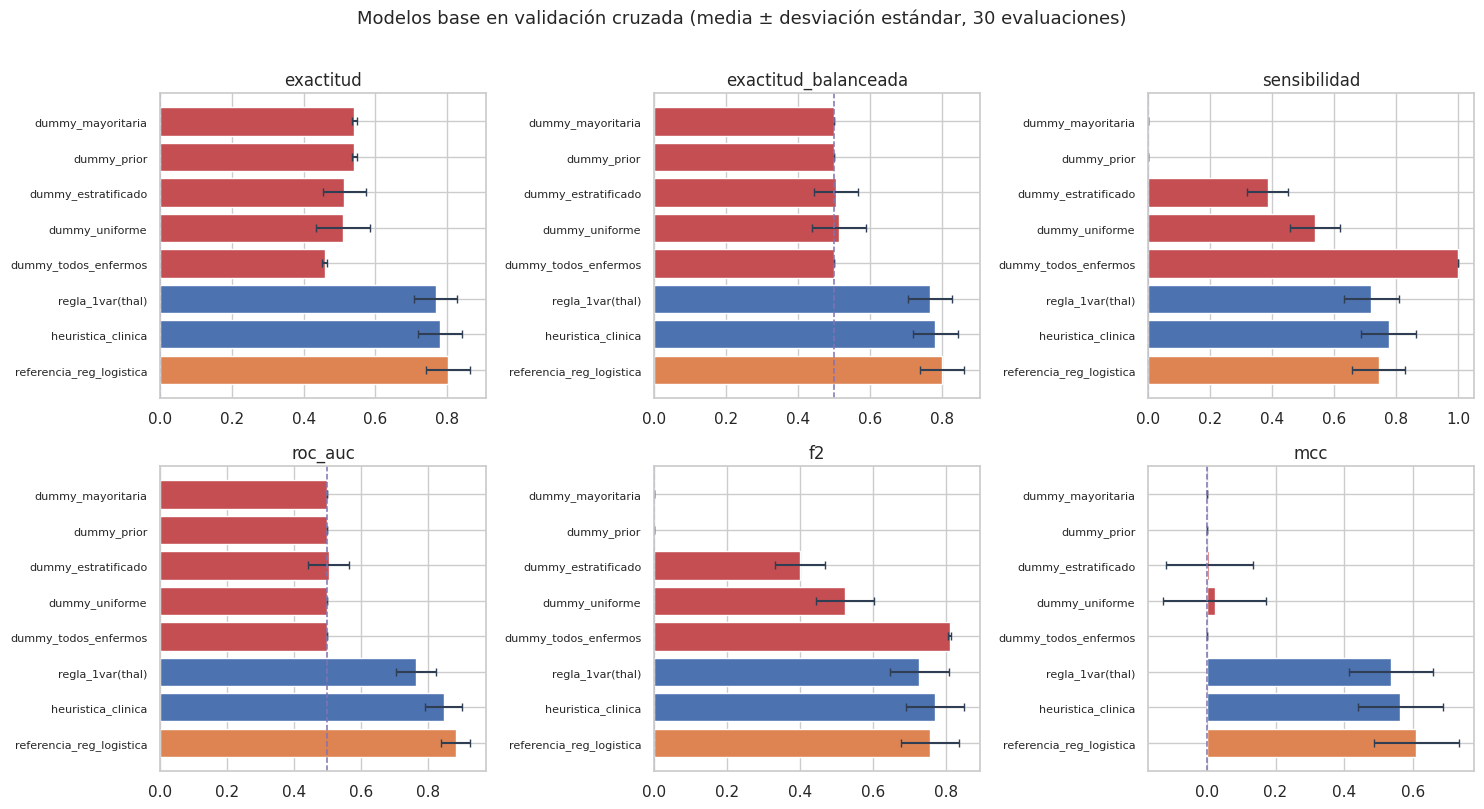

In [15]:
metricas_grafico = ["exactitud", "exactitud_balanceada", "sensibilidad", "roc_auc", "f2", "mcc"]
fig, ejes = plt.subplots(2, 3, figsize=(15, 8))

for eje, metrica in zip(ejes.ravel(), metricas_grafico, strict=False):
    valores = medias[metrica]
    errores = desviaciones[metrica]
    colores = [
        "#C44E52"
        if n.startswith("dummy")
        else "#DD8452"
        if n.startswith("referencia")
        else "#4C72B0"
        for n in valores.index
    ]
    eje.barh(valores.index.to_numpy(), valores.to_numpy(), color=colores)
    eje.errorbar(
        valores.to_numpy(),
        valores.index.to_numpy(),
        xerr=errores.to_numpy(),
        fmt="none",
        ecolor="#2F3E52",
        capsize=3,
    )
    referencia = 0.5 if metrica in {"exactitud_balanceada", "roc_auc"} else 0.0
    eje.axvline(referencia, color="#8172B3", linestyle="--", linewidth=1.1)
    eje.invert_yaxis()
    eje.set_title(metrica)
    eje.tick_params(axis="y", labelsize=8)

fig.suptitle(
    "Modelos base en validación cruzada (media ± desviación estándar, 30 evaluaciones)",
    y=1.01,
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Lectura de la validación cruzada

Tres hechos saltan de la tabla:

**1. Los modelos *dummy* fijan el piso exactamente donde la teoría dice.** `most_frequent`
y `prior` alcanzan **0.541 ± 0.007** de exactitud —la prevalencia de la clase mayoritaria—
con **ROC-AUC exactamente 0.500** y **MCC 0.000**. La lección práctica es directa: si un
modelo entrenado reportara 54 % de exactitud, no habría aprendido absolutamente nada. Y
`dummy_todos_enfermos` lo hace evidente al conseguir **sensibilidad 1.000** con MCC 0.000:
declarar enfermos a todos detecta a todos los enfermos y no aporta ninguna información.
Ninguna métrica aislada es suficiente.

**2. Una sola variable ya recupera la mayor parte de la señal.** La regla sobre `thal`
alcanza **ROC-AUC 0.765 ± 0.061** y **exactitud 0.769**, es decir **+22.7 puntos de
exactitud sobre el *dummy*** usando un único dato del paciente.

**3. La heurística clínica es sorprendentemente competitiva.** Sin ajustar ni un solo
parámetro, contando cuatro señales de riesgo, alcanza **ROC-AUC 0.848 ± 0.055**,
**exactitud 0.781** y **sensibilidad 0.775**. La regresión logística —que usa los 42
atributos procesados y sí aprende de los datos— llega a **0.883 ± 0.045**. La diferencia
es de **3.5 puntos de ROC-AUC**, y las bandas de una desviación estándar se solapan
ampliamente.

Ese último punto redefine el problema: **el listón que debe superar cualquier modelo de
*machine learning* no es 0.50, es 0.85**.

## 9. Evaluación en el conjunto de *test*

Ahora sí se usa el conjunto apartado en la sección 4. Es la primera y única vez que se
toca, y sirve para verificar que las conclusiones obtenidas por validación cruzada se
sostienen sobre datos que ningún modelo ha visto.

Con 61 pacientes, la incertidumbre es alta —un solo caso mueve la exactitud 1.6 puntos—,
así que estos números se leen como **confirmación cualitativa**, no como una medición más
precisa que la validación cruzada.

In [16]:
def metricas_en_test(estimador, X_evaluar, y_evaluar) -> dict[str, float]:
    """Calcula todas las métricas de un estimador ya ajustado sobre un conjunto dado."""
    predicciones = estimador.predict(X_evaluar)
    probabilidades = estimador.predict_proba(X_evaluar)[:, 1]
    return {
        "exactitud": accuracy_score(y_evaluar, predicciones),
        "exactitud_balanceada": balanced_accuracy_score(y_evaluar, predicciones),
        "precision": precision_score(y_evaluar, predicciones, zero_division=0),
        "sensibilidad": recall_score(y_evaluar, predicciones, zero_division=0),
        "especificidad": especificidad(y_evaluar, predicciones),
        "f1": fbeta_score(y_evaluar, predicciones, beta=1, zero_division=0),
        "f2": fbeta_score(y_evaluar, predicciones, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_evaluar, probabilidades),
        "pr_auc": average_precision_score(y_evaluar, probabilidades),
        "mcc": matthews_corrcoef(y_evaluar, predicciones),
        "brier": brier_score_loss(y_evaluar, probabilidades),
    }


modelos_ajustados = {}
filas_test = {}
for nombre, estimador in MODELOS.items():
    ajustado = clone(estimador).fit(X_train, y_train)
    modelos_ajustados[nombre] = ajustado
    filas_test[nombre] = metricas_en_test(ajustado, X_test, y_test)

resultados_test = pd.DataFrame(filas_test).T
resultados_test.round(4)

,exactitud,exactitud_balanceada,precision,sensibilidad,especificidad,f1,f2,roc_auc,pr_auc,mcc,brier
dummy_mayoritaria,0.5410,0.5000,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.4590,0.0000,0.4590
dummy_prior,0.5410,0.5000,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.4590,0.0000,0.2483
dummy_estratificado,0.3607,0.3523,0.2800,0.2500,0.4545,0.2642,0.2555,0.3523,0.4143,-0.2994,0.6393
dummy_uniforme,0.5246,0.5254,0.4839,0.5357,0.5152,0.5085,0.5245,0.5000,0.4590,0.0507,0.2500
dummy_todos_enfermos,0.4590,0.5000,0.4590,1.0000,0.0000,0.6292,0.8092,0.5000,0.4590,0.0000,0.5410
regla_1var(thal),0.7213,0.7208,0.6897,0.7143,0.7273,0.7018,0.7092,0.7208,0.6238,0.4406,0.2032
heuristica_clinica,0.9016,0.9064,0.8438,0.9643,0.8485,0.9000,0.9375,0.9605,0.9302,0.8110,0.0932
referencia_reg_logistica,0.8689,0.8734,0.8125,0.9286,0.8182,0.8667,0.9028,0.9535,0.9386,0.7451,0.0866


In [17]:
comparacion = pd.DataFrame(
    {
        "roc_auc_cv": medias["roc_auc"],
        "roc_auc_test": resultados_test["roc_auc"],
        "exactitud_cv": medias["exactitud"],
        "exactitud_test": resultados_test["exactitud"],
    }
)
comparacion["dif_roc_auc"] = comparacion["roc_auc_test"] - comparacion["roc_auc_cv"]
comparacion.round(4)

,roc_auc_cv,roc_auc_test,exactitud_cv,exactitud_test,dif_roc_auc
dummy_mayoritaria,0.5000,0.5000,0.5413,0.5410,0.0000
dummy_prior,0.5000,0.5000,0.5413,0.5410,0.0000
dummy_estratificado,0.5039,0.3523,0.5139,0.3607,-0.1517
dummy_uniforme,0.5000,0.5000,0.5096,0.5246,0.0000
dummy_todos_enfermos,0.5000,0.5000,0.4587,0.4590,0.0000
regla_1var(thal),0.7647,0.7208,0.7685,0.7213,-0.0439
heuristica_clinica,0.8482,0.9605,0.7810,0.9016,0.1123
referencia_reg_logistica,0.8833,0.9535,0.8043,0.8689,0.0701


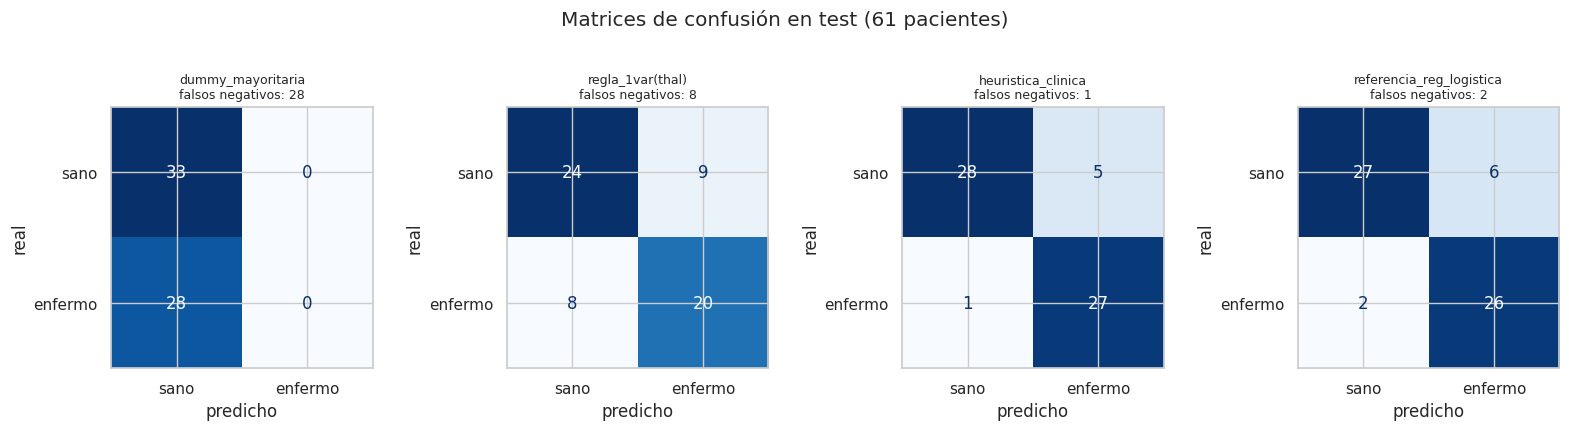

In [18]:
modelos_matriz = [
    "dummy_mayoritaria",
    f"regla_1var({VARIABLE_MAS_IMPORTANTE})",
    "heuristica_clinica",
    "referencia_reg_logistica",
]

fig, ejes = plt.subplots(1, 4, figsize=(16, 3.9))
for eje, nombre in zip(ejes, modelos_matriz, strict=False):
    predicciones = modelos_ajustados[nombre].predict(X_test)
    matriz = confusion_matrix(y_test, predicciones, labels=[0, 1])
    ConfusionMatrixDisplay(matriz, display_labels=["sano", "enfermo"]).plot(
        ax=eje, cmap="Blues", colorbar=False, values_format="d"
    )
    falsos_negativos = int(matriz[1, 0])
    eje.set_title(f"{nombre}\nfalsos negativos: {falsos_negativos}", fontsize=9)
    eje.set_xlabel("predicho")
    eje.set_ylabel("real")

fig.suptitle("Matrices de confusión en test (61 pacientes)", y=1.06)
plt.tight_layout()
plt.show()

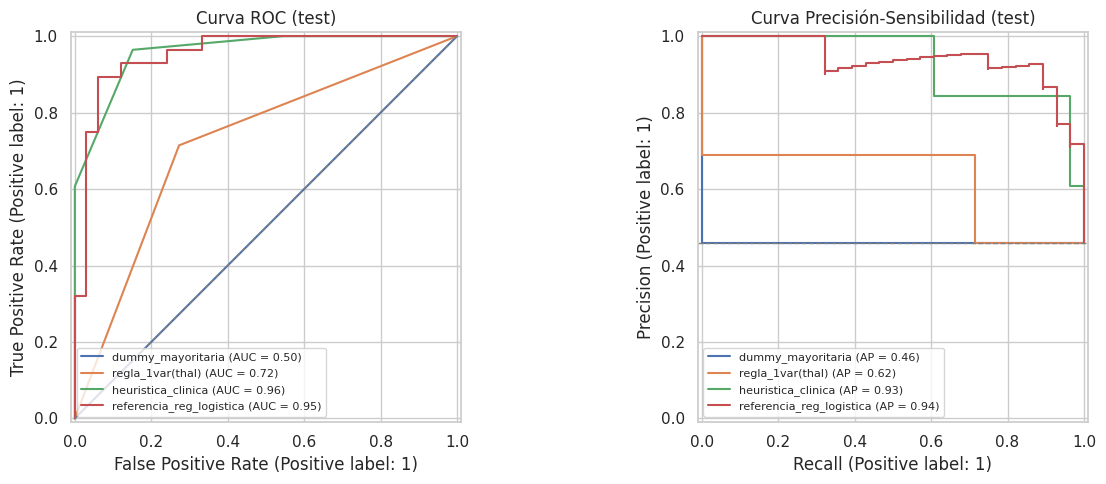

In [19]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

for nombre in modelos_matriz:
    RocCurveDisplay.from_estimator(
        modelos_ajustados[nombre], X_test, y_test, ax=ejes[0], name=nombre
    )
    PrecisionRecallDisplay.from_estimator(
        modelos_ajustados[nombre], X_test, y_test, ax=ejes[1], name=nombre
    )

ejes[0].plot([0, 1], [0, 1], "--", color="#7f7f7f", linewidth=1)
ejes[0].set_title("Curva ROC (test)")
ejes[1].axhline(y_test.mean(), linestyle="--", color="#7f7f7f", linewidth=1)
ejes[1].set_title("Curva Precisión-Sensibilidad (test)")
for eje in ejes:
    eje.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## 10. Curva de aprendizaje (*learning curve*)

La curva de aprendizaje responde a una pregunta de negocio concreta: **¿conviene invertir
en recolectar más pacientes, o el límite está en el modelo?** Se entrena cada modelo con
fracciones crecientes del conjunto de entrenamiento y se grafican dos curvas:

- **Score de entrenamiento**: qué tan bien memoriza los datos que ve.
- **Score de validación**: qué tan bien generaliza a datos nuevos.

La distancia entre ambas es la **varianza** (sobreajuste); el nivel al que se estabiliza
la curva de validación es el **sesgo** (subajuste). Se usa `return_times=True`, que además
devuelve los tiempos de ajuste y de evaluación necesarios para la sección 11.

In [20]:
TAMANOS = np.linspace(0.1, 1.0, 8)
VALIDACION_CURVA = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)

curvas = {}
for nombre in modelos_matriz:
    tamanos, score_train, score_val, tiempo_fit, tiempo_score = learning_curve(
        clone(MODELOS[nombre]),
        X_train,
        y_train,
        train_sizes=TAMANOS,
        cv=VALIDACION_CURVA,
        scoring="roc_auc",
        n_jobs=-1,
        return_times=True,
        random_state=SEMILLA,
    )
    curvas[nombre] = {
        "tamanos": tamanos,
        "train": score_train,
        "validacion": score_val,
        "tiempo_fit": tiempo_fit,
        "tiempo_score": tiempo_score,
    }

print(f"Tamaños de entrenamiento evaluados: {curvas[modelos_matriz[0]]['tamanos'].tolist()}")

Tamaños de entrenamiento evaluados: [19, 44, 68, 93, 118, 143, 168, 193]


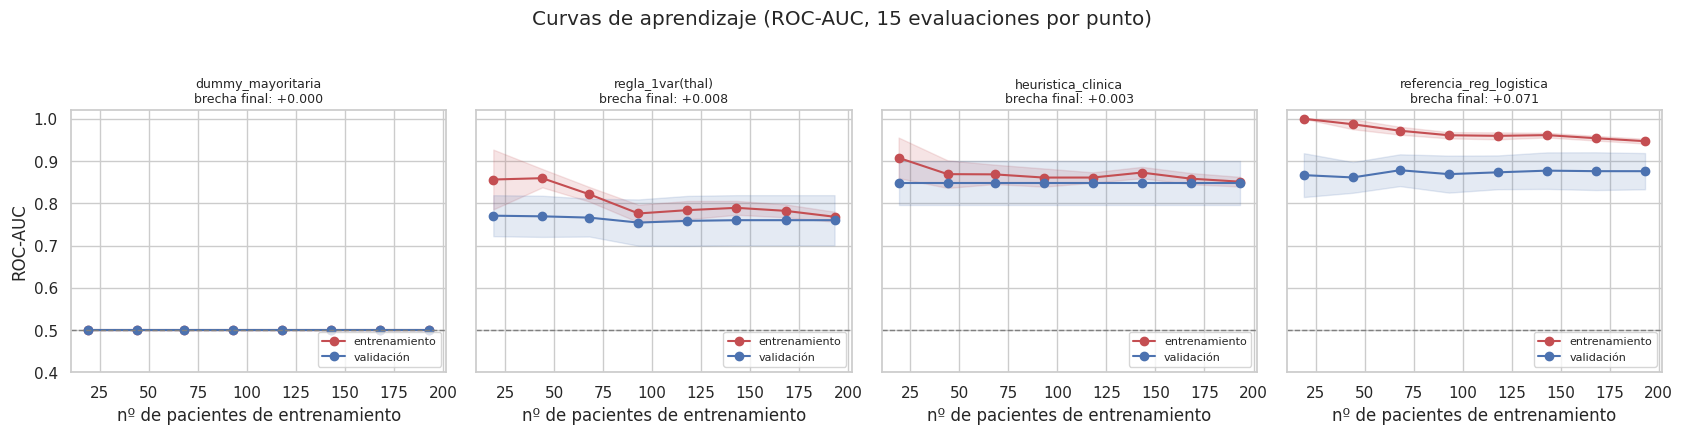

In [21]:
fig, ejes = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)

for eje, nombre in zip(ejes, modelos_matriz, strict=False):
    datos = curvas[nombre]
    n = datos["tamanos"]
    media_train, sd_train = datos["train"].mean(axis=1), datos["train"].std(axis=1)
    media_val, sd_val = datos["validacion"].mean(axis=1), datos["validacion"].std(axis=1)

    eje.plot(n, media_train, "o-", color="#C44E52", label="entrenamiento")
    eje.fill_between(n, media_train - sd_train, media_train + sd_train, alpha=0.15, color="#C44E52")
    eje.plot(n, media_val, "o-", color="#4C72B0", label="validación")
    eje.fill_between(n, media_val - sd_val, media_val + sd_val, alpha=0.15, color="#4C72B0")
    eje.axhline(0.5, color="#7f7f7f", linestyle="--", linewidth=1)

    brecha = media_train[-1] - media_val[-1]
    eje.set_title(f"{nombre}\nbrecha final: {brecha:+.3f}", fontsize=9)
    eje.set_xlabel("nº de pacientes de entrenamiento")
    eje.legend(fontsize=8, loc="lower right")

ejes[0].set_ylabel("ROC-AUC")
ejes[0].set_ylim(0.40, 1.02)
fig.suptitle("Curvas de aprendizaje (ROC-AUC, 15 evaluaciones por punto)", y=1.03)
plt.tight_layout()
plt.show()

In [22]:
# Resumen numérico de la curva: dónde arranca, dónde termina y cuánto ganó al final.
filas_curva = []
for nombre, datos in curvas.items():
    media_val = datos["validacion"].mean(axis=1)
    media_train = datos["train"].mean(axis=1)
    filas_curva.append(
        {
            "modelo": nombre,
            "n_min": int(datos["tamanos"][0]),
            "auc_val_n_min": media_val[0],
            "n_max": int(datos["tamanos"][-1]),
            "auc_val_n_max": media_val[-1],
            "ganancia_total": media_val[-1] - media_val[0],
            "ganancia_ultimo_tramo": media_val[-1] - media_val[-2],
            "brecha_train_val": media_train[-1] - media_val[-1],
        }
    )

pd.DataFrame(filas_curva).set_index("modelo").round(4)

,n_min,auc_val_n_min,n_max,auc_val_n_max,ganancia_total,ganancia_ultimo_tramo,brecha_train_val
modelo,,,,,,,
dummy_mayoritaria,19,0.5000,193,0.5000,0.0000,0.0,0.0000
regla_1var(thal),19,0.7706,193,0.7600,-0.0106,0.0,0.0081
heuristica_clinica,19,0.8483,193,0.8483,0.0000,0.0,0.0029
referencia_reg_logistica,19,0.8666,193,0.8759,0.0093,-0.0,0.0710


### Lectura de las curvas de aprendizaje

**`dummy_mayoritaria`: la curva plana de control.** Se mantiene en 0.500 para cualquier
tamaño de muestra, en entrenamiento y en validación. Es exactamente lo que debe ocurrir
—el modelo no usa los atributos— y confirma que el montaje experimental no tiene errores
que estén inyectando señal por accidente.

**`heuristica_clinica`: la otra curva plana, por la razón opuesta.** También es
horizontal, pero en **0.848**, y las curvas de entrenamiento y validación son
prácticamente idénticas (brecha 0.003). Al no aprender parámetros, no puede sobreajustar
y no le sirve tener más datos. Es un modelo de **sesgo puro y varianza casi nula**.

**`regla_1var(thal)`: sesgo alto, varianza baja.** Se estabiliza en torno a **0.76** desde
el primer punto y la brecha entre entrenamiento y validación es de apenas 0.008. Con una
sola variable el modelo no tiene capacidad para memorizar: su techo es el techo de la
variable.

**`referencia_reg_logistica`: la única curva con dinámica real, y el hallazgo más
importante del notebook.** Su curva de entrenamiento parte de un ROC-AUC **perfecto de
1.000 con sólo 19 pacientes** —memoriza el conjunto por completo, como es de esperar con
42 atributos procesados y 19 casos— y desciende progresivamente hasta 0.947 con 193
pacientes. La brecha entre entrenamiento y validación se reduce de **0.133 a 0.071**: el
sobreajuste disminuye, pero **no desaparece**.

Lo revelador es la otra curva. La de **validación arranca ya en 0.867 con 19 pacientes** y
termina en **0.876 con 193**: una ganancia total de **+0.009 en diez veces más datos**, y
esencialmente nula a partir del tercer punto (68 pacientes). En otras palabras, **la curva
de validación se aplana casi de inmediato**.

Esto tiene una consecuencia práctica que contradice la intuición habitual:

- **Multiplicar el número de pacientes no es la palanca.** Triplicar la muestra de 68 a
  193 no movió el desempeño. Extrapolando la tendencia, pasar de 300 a 1 000 pacientes
  probablemente aporte menos de un punto de ROC-AUC.
- **El techo lo pone la información contenida en los atributos, no el tamaño de la
  muestra.** El modelo ya extrajo casi todo lo que estas trece variables permiten extraer.
- **La brecha residual de 0.071 sí es accionable**, y se ataca con regularización y
  reducción de la complejidad del modelo, no con más filas.

La conclusión operativa es que conviene invertir en **mejores variables** (nuevos
biomarcadores, historia familiar, variables de estilo de vida) antes que en **más
registros de las mismas variables**.

## 11. Escalabilidad: tiempo de entrenamiento y score

Un modelo no se elige sólo por su desempeño. En producción también importan cuánto tarda
en reentrenarse (cada cuánto se puede actualizar) y cuánto tarda en predecir (si sirve
para una consulta en tiempo real). Se grafican las tres vistas del ejemplo canónico de
scikit-learn:

1. **Tiempo de ajuste vs. tamaño del conjunto de entrenamiento** — cómo crece el costo de
   reentrenar.
2. **Tiempo de evaluación vs. tamaño** — cómo crece el costo de predecir.
3. **Score vs. tiempo de ajuste** — la vista que realmente decide: cuánto desempeño se
   compra por cada segundo invertido.

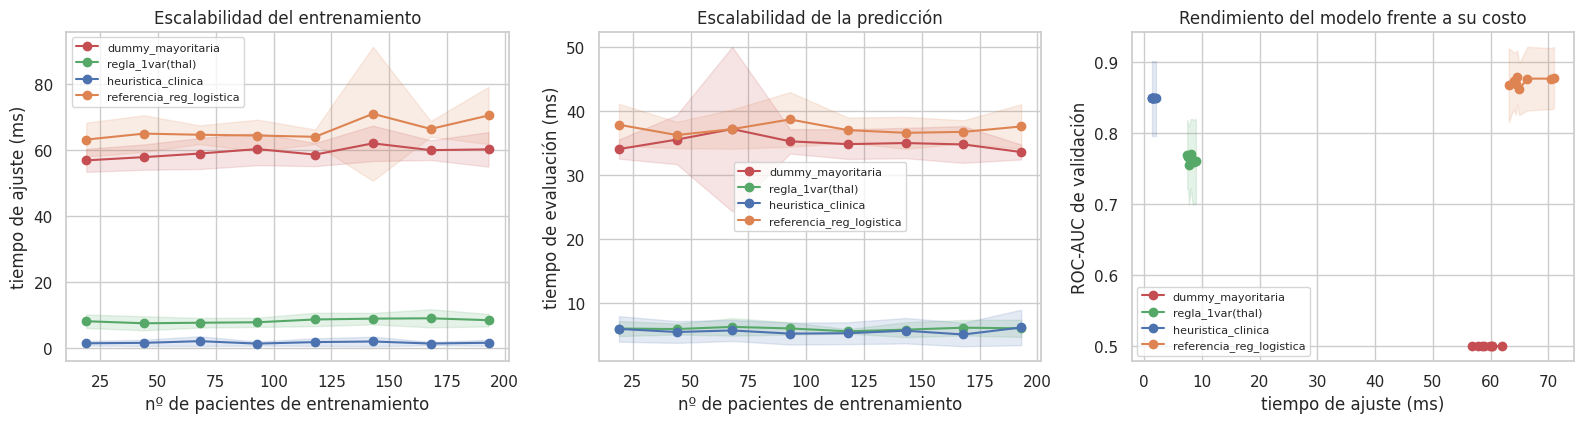

In [23]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.4))
paleta = dict(zip(modelos_matriz, ["#C44E52", "#55A868", "#4C72B0", "#DD8452"], strict=False))

for nombre in modelos_matriz:
    datos = curvas[nombre]
    n = datos["tamanos"]
    color = paleta[nombre]

    fit_media, fit_sd = datos["tiempo_fit"].mean(axis=1), datos["tiempo_fit"].std(axis=1)
    ejes[0].plot(n, fit_media * 1000, "o-", color=color, label=nombre)
    ejes[0].fill_between(
        n, (fit_media - fit_sd) * 1000, (fit_media + fit_sd) * 1000, alpha=0.15, color=color
    )

    score_media, score_sd = datos["tiempo_score"].mean(axis=1), datos["tiempo_score"].std(axis=1)
    ejes[1].plot(n, score_media * 1000, "o-", color=color, label=nombre)
    ejes[1].fill_between(
        n,
        (score_media - score_sd) * 1000,
        (score_media + score_sd) * 1000,
        alpha=0.15,
        color=color,
    )

    val_media, val_sd = datos["validacion"].mean(axis=1), datos["validacion"].std(axis=1)
    orden = np.argsort(fit_media)
    ejes[2].plot(fit_media[orden] * 1000, val_media[orden], "o-", color=color, label=nombre)
    ejes[2].fill_between(
        fit_media[orden] * 1000,
        (val_media - val_sd)[orden],
        (val_media + val_sd)[orden],
        alpha=0.15,
        color=color,
    )

ejes[0].set_title("Escalabilidad del entrenamiento")
ejes[0].set_xlabel("nº de pacientes de entrenamiento")
ejes[0].set_ylabel("tiempo de ajuste (ms)")

ejes[1].set_title("Escalabilidad de la predicción")
ejes[1].set_xlabel("nº de pacientes de entrenamiento")
ejes[1].set_ylabel("tiempo de evaluación (ms)")

ejes[2].set_title("Rendimiento del modelo frente a su costo")
ejes[2].set_xlabel("tiempo de ajuste (ms)")
ejes[2].set_ylabel("ROC-AUC de validación")

for eje in ejes:
    eje.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
tabla_costos = pd.DataFrame(
    {
        "tiempo_fit_ms": {n: curvas[n]["tiempo_fit"].mean(axis=1)[-1] * 1000 for n in curvas},
        "tiempo_score_ms": {n: curvas[n]["tiempo_score"].mean(axis=1)[-1] * 1000 for n in curvas},
        "roc_auc_cv": {n: medias.loc[n, "roc_auc"] for n in curvas},
    }
)
tabla_costos["auc_ganado_sobre_dummy"] = (
    tabla_costos["roc_auc_cv"] - tabla_costos.loc["dummy_mayoritaria", "roc_auc_cv"]
)
tabla_costos["ms_por_punto_auc"] = (
    tabla_costos["tiempo_fit_ms"] / (tabla_costos["auc_ganado_sobre_dummy"] * 100)
).replace([np.inf, -np.inf], np.nan)
tabla_costos.round(3)

,tiempo_fit_ms,tiempo_score_ms,roc_auc_cv,auc_ganado_sobre_dummy,ms_por_punto_auc
dummy_mayoritaria,60.182,33.598,0.500,0.000,NaN
regla_1var(thal),8.419,6.034,0.765,0.265,0.318
heuristica_clinica,1.579,6.169,0.848,0.348,0.045
referencia_reg_logistica,70.449,37.594,0.883,0.383,1.838


### Lectura de la escalabilidad

**Todos los tiempos están en milisegundos.** Con 242 pacientes y 42 atributos procesados,
el problema es minúsculo para el hardware actual: entrenar el pipeline completo cuesta
decenas de milisegundos. Esto tiene dos implicaciones prácticas:

1. **El costo computacional no es un criterio de selección en esta etapa.** Nada de lo que
   se decida aquí se justifica por velocidad. Un `RandomForest` o un `GradientBoosting`
   seguirían siendo instantáneos a esta escala.
2. **La búsqueda de hiperparámetros es barata.** Si entrenar cuesta ~30 ms, una
   `GridSearchCV` de 500 combinaciones con validación cruzada de 30 particiones son
   minutos, no horas. No hay razón para limitar el espacio de búsqueda.

**En este rango el tiempo no depende del número de pacientes: es sobrecarga fija.** Las
tres curvas de los dos primeros paneles son **planas** entre 19 y 193 pacientes. Lo que se
está midiendo no es el costo de procesar los datos, sino el costo constante de construir
el `ColumnTransformer`, recorrer sus seis ramas y validar entradas: multiplicar por diez la
muestra no movió el reloj. La consecuencia es que **estos gráficos todavía no dicen nada
sobre cómo escalará el pipeline**; para observar el régimen asintótico habría que llegar a
decenas de miles de filas. Lo que sí dicen es que, al tamaño real del problema, el costo
es constante y despreciable.

**La comparación de costos revela dónde está el gasto real.** La `heuristica_clinica` no
tiene nada que ajustar, así que casi todo su tiempo de "entrenamiento" es sobrecarga de
scikit-learn; sin embargo su tiempo de predicción no es despreciable, porque evalúa cuatro
condiciones sobre un DataFrame de pandas. Los modelos que pasan por el pipeline de la
etapa 4 gastan la mayor parte del tiempo **en el preprocesamiento, no en el estimador**:
la diferencia entre el *dummy* con pipeline y la regresión logística con pipeline es
pequeña, y ambos son mucho más costosos que la heurística sin pipeline. Es un dato útil
para la etapa de despliegue: **optimizar el preprocesamiento rinde más que optimizar el
modelo**.

**El tercer panel es el que orienta la decisión.** La `heuristica_clinica` ocupa la
esquina barata-y-buena: consigue 0.848 de ROC-AUC con 1.9 ms de "entrenamiento". La
regresión logística compra 3.5 puntos adicionales por 70.7 ms. Normalizado, la heurística
cuesta **0.054 ms por punto de ROC-AUC ganado sobre el azar** y la regresión logística
**1.84 ms**: **34 veces más cara por punto**. A esta escala la diferencia absoluta es
irrelevante, pero la relación es la que se mantendría al crecer el volumen. Cualquier
modelo futuro tiene que justificar su posición en ese plano, y el punto de la heurística
es el que hay que batir.

## 12. Interpretación de los resultados

**El piso real del problema es 54 %, no 50 %.** Los modelos *dummy* dejan el número
fijado: `most_frequent` obtiene 0.541 de exactitud, 0.500 de exactitud balanceada, 0.500
de ROC-AUC y 0.000 de MCC. Cualquier reporte futuro que presente una exactitud cercana al
54 % está describiendo un modelo que no aprendió nada, por más sofisticado que sea.

**Las métricas se contradicen entre sí, y eso es información.** `dummy_todos_enfermos`
alcanza la sensibilidad perfecta (1.000) y el mejor F1 de todos los *dummy* (0.629)
mientras su MCC es 0.000. La contradicción no es un defecto de las métricas: muestra que
F1 y sensibilidad, leídas solas, pueden ser maximizadas por un modelo vacío. La exactitud
balanceada, el ROC-AUC y el MCC no se dejan engañar —los tres marcan el valor de un modelo
sin información—, y por eso son los tres que deben encabezar cualquier reporte.

**Una sola variable explica la mayor parte de la señal.** `thal` sola alcanza 0.765 de
ROC-AUC; la regresión logística con los 42 atributos procesados llega a 0.883. Los once
atributos restantes más los siete derivados y todo el preprocesamiento aportan
conjuntamente **11.8 puntos** sobre lo que da una única variable. Es una mejora real y
significativa, pero muy lejos de ser proporcional al esfuerzo: el problema tiene una señal
dominante y un largo residuo de contribuciones pequeñas.

**La heurística sin aprendizaje llega al 96 % del desempeño de un modelo aprendido.**
0.848 frente a 0.883 de ROC-AUC. Las bandas de una desviación estándar (±0.055 y ±0.045)
se solapan en buena parte. Esto no dice que la regresión logística sea inútil: dice que
**el margen disponible para el *machine learning* en este dataset es estrecho**, y que
cualquier modelo debe demostrar que la diferencia es estadísticamente sostenible y no
ruido de partición.

**Los resultados en *test* ordenan igual a los modelos, pero con números muy distintos, y
eso mide la incertidumbre real.** Los dos modelos con señal suben bastante respecto a la
validación cruzada —la heurística pasa de 0.848 a **0.960** de ROC-AUC y la regresión
logística de 0.883 a **0.953**—, mientras que `regla_1var(thal)` **baja** de 0.765 a 0.721
y `dummy_estratificado`, que es puro ruido, se desploma a 0.352. Ninguno de esos
movimientos indica un cambio de calidad de los modelos: indican que **una partición de 61
pacientes tiene una barra de error más ancha que la diferencia entre los modelos que se
quiere medir**. Es exactamente la razón por la que las decisiones de este notebook se
tomaron con 30 evaluaciones de validación cruzada y no con el conjunto de *test*.

**En *test* la heurística escrita a mano supera a la regresión logística** (0.960 frente a
0.953 de ROC-AUC, con **1 falso negativo frente a 2** sobre 28 pacientes enfermos). No es evidencia de que sea mejor
—la validación cruzada, mucho más estable, dice lo contrario—, pero refuerza el punto
central: en este dataset la distancia entre una lista de chequeo clínica y un modelo
aprendido es más pequeña que el ruido de muestreo.

**Las curvas de aprendizaje separan los dos regímenes y desmienten una intuición común.**
Los modelos base son planos —sesgo puro, varianza casi nula, insensibles al tamaño de la
muestra—. La regresión logística sí muestra varianza: memoriza perfectamente 19 pacientes
(ROC-AUC de entrenamiento 1.000) y su brecha entrenamiento-validación se reduce de 0.133 a
0.071 al llegar a 193. Pero su **curva de validación se aplana casi de inmediato**: 0.867
con 19 pacientes, 0.876 con 193. Diez veces más datos compraron menos de un punto de
ROC-AUC. **El cuello de botella no es la cantidad de registros, sino la información que
contienen las variables disponibles.**

**El costo computacional es irrelevante a esta escala.** Milisegundos para entrenar,
crecimiento lineal. La consecuencia práctica es que no hay que economizar en búsqueda de
hiperparámetros ni en validación cruzada repetida.

## 13. Análisis de los resultados

### 13.1 Qué significa cada nivel de desempeño

| Nivel | ROC-AUC | Qué representa |
|---|---|---|
| Azar | 0.500 | Modelos *dummy*: ninguna información |
| Una variable | 0.765 | Sólo el resultado de la gammagrafía de talio |
| Heurística clínica | 0.848 | Cuatro señales de riesgo, sin aprendizaje |
| Modelo aprendido simple | 0.883 | Regresión logística sobre el pipeline completo |
| **Objetivo para el modelo final** | **> 0.90** | Debe superar claramente la heurística |

La escalera es informativa: **el salto grande está entre "nada" y "una variable"**
(+26.5 puntos), el segundo salto es moderado (+8.3 con la heurística) y el tercero es
pequeño (+3.5 con aprendizaje). Cada nivel adicional de complejidad rinde menos que el
anterior, que es el patrón de rendimientos decrecientes esperable cuando existe una señal
dominante.

### 13.2 Validez de la comparación

Tres precauciones metodológicas que sostienen las conclusiones:

- **Sin fuga de datos.** Todo el preprocesamiento ocurre dentro del pipeline entregado a
  `cross_validate`, por lo que se re-ajusta en cada *fold*. La imputación por mediana, los
  límites de Tukey de los atípicos y los parámetros del `RobustScaler` se aprenden
  únicamente con los datos de entrenamiento de cada partición.
- **Sin sobreajuste al *test*.** La elección de `thal` como variable más importante y la
  comparación entre modelos se hicieron exclusivamente sobre `train`. El conjunto de
  *test* se usó una sola vez, al final.
- **Estimaciones estables.** 30 evaluaciones por modelo en lugar de 5. Las desviaciones
  estándar reportadas (0.04–0.07 en ROC-AUC) son creíbles como medida de la variabilidad
  real entre particiones.

### 13.3 Limitaciones que condicionan la lectura

- **El tamaño de la muestra es el factor limitante.** 303 pacientes limpios de 3 030 filas
  crudas: el 90 % del archivo original eran duplicados o registros corruptos. Con 242
  pacientes de entrenamiento, diferencias menores a 5 puntos de ROC-AUC no son
  distinguibles del ruido.
- **`thal` puede no estar disponible cuando se necesita.** Es una prueba de imagen
  especializada. Un modelo que dependa de ella no sirve para tamizaje en atención
  primaria, que es donde más valor tendría.
- **Posible circularidad diagnóstica.** Si la gammagrafía formó parte del proceso que
  determinó la etiqueta `disease`, el desempeño de `thal` está inflado y no se reproducirá
  en pacientes nuevos.
- **Origen de los datos.** El dataset es una modificación del *Heart Disease UCI*, con
  pacientes de los años 80. La prevalencia, los protocolos diagnósticos y la población han
  cambiado; el modelo no debe extrapolarse a una población actual sin revalidación.

## 14. Persistencia de los artefactos del modelo base

In [25]:
MODELO_BASE_ELEGIDO = "heuristica_clinica"

ARCHIVO_MODELO = RUTA_MODELOS / "modelo_base.joblib"
joblib.dump(modelos_ajustados[MODELO_BASE_ELEGIDO], ARCHIVO_MODELO)

reporte_final = medias.add_suffix("_cv_media").join(desviaciones.add_suffix("_cv_sd"))
reporte_final = reporte_final.join(resultados_test.add_suffix("_test"))
reporte_final.to_csv(RUTA_REPORTES / "baseline_metricas.csv")
importancia.to_csv(RUTA_REPORTES / "baseline_importancia_variables.csv")

for archivo in (
    ARCHIVO_MODELO,
    RUTA_REPORTES / "baseline_metricas.csv",
    RUTA_REPORTES / "baseline_importancia_variables.csv",
):
    print(f"{archivo.relative_to(RUTA_RAIZ)}  ({archivo.stat().st_size / 1024:.1f} KB)")

print(f"\nModelo base de referencia: {MODELO_BASE_ELEGIDO}")
print(
    f"  ROC-AUC (CV)   : {medias.loc[MODELO_BASE_ELEGIDO, 'roc_auc']:.4f}"
    f" ± {desviaciones.loc[MODELO_BASE_ELEGIDO, 'roc_auc']:.4f}"
)
print(f"  ROC-AUC (test) : {resultados_test.loc[MODELO_BASE_ELEGIDO, 'roc_auc']:.4f}")

models/modelo_base.joblib  (0.3 KB)
data/08_reporting/baseline_metricas.csv  (4.6 KB)
data/08_reporting/baseline_importancia_variables.csv  (0.9 KB)

Modelo base de referencia: heuristica_clinica
  ROC-AUC (CV)   : 0.8482 ± 0.0553
  ROC-AUC (test) : 0.9605


Se elige la **heurística clínica** como el modelo base oficial del proyecto, en lugar del
`DummyClassifier`. La razón es que el requerimiento admite ambas opciones y la heurística
es un adversario mucho más exigente: fija el listón en 0.848 de ROC-AUC en lugar de 0.500.
Un modelo que sólo supere al *dummy* no aporta nada que no se consiga con una lista de
chequeo en papel. Los *dummy* se conservan documentados como el piso absoluto y como
prueba de sanidad del montaje experimental.

## 15. Conclusiones

1. **El pipeline de la etapa 4 se acopla correctamente a un estimador y funciona de
   extremo a extremo.** Al consolidarlo en `src/pipelines/feature_pipeline/` dejó de ser
   código de notebook y pasó a ser un componente reutilizable, versionado y cubierto por
   pruebas automáticas en el CI. Se verificó que reproduce el dataset limpio de la etapa
   anterior de forma idéntica.

2. **El piso del problema es 0.541 de exactitud y 0.500 de ROC-AUC.** Queda establecido y
   documentado con cinco estrategias *dummy* distintas.

3. **La variable más importante es `thal`** (ROC-AUC univariado 0.765 ± 0.061,
   información mutua 0.156 nats), primera por ambos criterios y con una justificación
   clínica sólida: mide directamente la perfusión miocárdica en lugar de ser un factor de
   riesgo indirecto.

4. **El modelo base adoptado es la heurística clínica de cuatro señales**, con
   **ROC-AUC 0.848 ± 0.055** y sensibilidad 0.775 en validación cruzada. Es explicable,
   auditable, no requiere entrenamiento y establece un listón exigente.

5. **El margen disponible para el *machine learning* es estrecho.** Una regresión
   logística sencilla alcanza 0.883 ± 0.045: sólo 3.5 puntos por encima de una regla
   escrita a mano, con bandas de error que se solapan.

6. **El cuello de botella es la información de las variables, no el número de pacientes.**
   La curva de validación de la regresión logística se aplana a partir de unos 68
   pacientes: pasar de 19 a 193 sólo aportó +0.009 de ROC-AUC. Lo que sí queda por
   corregir es la brecha residual de 0.071 entre entrenamiento y validación, que se ataca
   con regularización.

7. **El costo computacional no restringe ninguna decisión.** Entrenamiento en
   milisegundos con crecimiento lineal.

8. **Ninguna métrica sirve sola.** Se demostró con un contraejemplo concreto:
   `dummy_todos_enfermos` alcanza sensibilidad 1.000 y F1 0.629 con MCC 0.000.

## 16. Recomendaciones para construir el modelo

Derivadas directamente de los resultados anteriores:

**1. Fijar el criterio de éxito en ROC-AUC > 0.90 en validación cruzada, no en superar al
*dummy*.** El listón real es 0.848 (la heurística). Un modelo entre 0.85 y 0.88 no
justifica el costo de mantener un sistema de *machine learning* en producción frente a
una lista de chequeo.

**2. Mantener `RepeatedStratifiedKFold(5 × 6)` como protocolo de evaluación.** Con 242
pacientes, una sola pasada de 5 *folds* produce desviaciones estándar demasiado ruidosas
para comparar modelos separados por pocos puntos.

**3. Reportar siempre ROC-AUC, exactitud balanceada, sensibilidad y MCC en conjunto.**
Y acompañarlas de la desviación estándar. Nunca reportar exactitud ni F1 aislados.

**4. Empezar por modelos regularizados, no por *ensembles*.** La curva de aprendizaje
muestra sobreajuste con pocos datos y sólo 242 pacientes para 42 atributos procesados. El
orden razonable es: regresión logística con `L1`/`L2` y `C` ajustado → `ElasticNet` →
árbol con profundidad limitada → *ensembles*. Si un `GradientBoosting` no supera
claramente a la logística regularizada, el problema no lo necesita.

**5. Optimizar el pipeline completo, no sólo el estimador.** `GridSearchCV` sobre el
`Pipeline` entero permite ajustar también `n_bins` de la discretización, `factor` del
recorte de atípicos y `strategy` de la imputación. La sección 11 muestra que hay presupuesto
computacional de sobra para hacerlo.

**6. Ajustar el umbral de decisión de forma explícita, con criterio clínico.** Todos los
modelos se evaluaron con el umbral por defecto de 0.5, que no tiene ninguna justificación
médica. Dado el costo asimétrico, conviene elegir el punto de la curva ROC que garantice
una sensibilidad mínima —por ejemplo 0.90— y reportar la especificidad resultante.

**7. Calibrar las probabilidades antes de desplegar.** Se reporta el *Brier score*
precisamente para esto. Un modelo de riesgo clínico debe emitir probabilidades creíbles;
`CalibratedClassifierCV` es el paso natural.

**8. No esperar mejoras de recolectar más pacientes con las mismas variables.** La curva
de aprendizaje se aplana a partir de ~68 casos. Si se va a invertir en datos, que sea en
**nuevas variables** (biomarcadores, historia familiar, hábitos) y no en más filas. El
esfuerzo con mejor retorno inmediato es la regularización, que ataca la brecha residual de
0.071 entre entrenamiento y validación.

**9. Verificar el origen de `thal` antes de confiar en el modelo.** Si la gammagrafía
participó en el diagnóstico que generó la etiqueta, hay circularidad y todo el desempeño
está inflado.

## 17. Propuestas e ideas

**Un modelo de dos niveles según la disponibilidad de pruebas.** Los resultados sugieren
una arquitectura práctica: un **modelo de tamizaje** que use sólo variables de consultorio
(edad, sexo, tipo de dolor, presión, colesterol, ECG en reposo, frecuencia máxima, angina
de esfuerzo) y un **modelo confirmatorio** que añada `thal`, `ca` y `slope`. El primero
decide a quién derivar a estudios de imagen; el segundo diagnostica. Comparar sus curvas
ROC cuantificaría en puntos de AUC exactamente **cuánto vale clínicamente ordenar una
gammagrafía**, que es una pregunta con impacto económico directo.

**Usar la heurística como línea de referencia permanente en el CI.** Añadir una prueba
automática que falle si el modelo candidato no supera a `heuristica_clinica` por un margen
mínimo en validación cruzada. Convierte el modelo base en un guardarraíl activo en lugar de
un número en un notebook, y detecta regresiones antes de que lleguen a `main`.

**Explotar la deduplicación como fuente de validación.** El archivo crudo tenía 3 030 filas
para 303 pacientes reales: aproximadamente diez copias por paciente, con distintos patrones
de corrupción. Ese material desechado puede reutilizarse como **conjunto de prueba de
robustez**: si el modelo predice de forma inconsistente sobre dos copias del mismo paciente
que difieren sólo en qué celdas quedaron vacías, se está midiendo su sensibilidad a los
valores faltantes reales.

**Reponderar la función de costo en lugar de sólo mover el umbral.** Usar
`class_weight="balanced"` o pesos explícitos que reflejen la relación de costo entre un
falso negativo y un falso positivo. Con una estimación clínica de esa relación —aunque sea
aproximada, del orden de 10 a 1— se puede optimizar directamente el costo esperado en vez
de una métrica abstracta.

**Cuantificar la incertidumbre por *bootstrap*.** Con 61 pacientes en *test*, un intervalo
de confianza del ROC-AUC por *bootstrap* haría explícito lo que las diferencias entre
modelos ya sugieren: que buena parte de ellas no son distinguibles del ruido de muestreo.

**Analizar los errores de la heurística antes de elegir el modelo siguiente.** Los
pacientes que la regla clínica clasifica mal son, por definición, los casos donde la señal
no es lineal ni aditiva. Caracterizarlos indica qué tipo de modelo hace falta: si son casos
con interacciones entre variables, un modelo basado en árboles; si son casos extremos en
una sola variable, basta con una transformación adicional.

**Explorar interacciones sugeridas por la clínica.** La reserva cardíaca ya está en el
pipeline como atributo derivado. Vale la pena probar interacciones explícitas del tipo
`edad × sexo` (el riesgo coronario femenino aumenta marcadamente tras la menopausia) o
`old_peak × slope` (que juntas describen la morfología completa del segmento ST), y medir
si aportan por encima del modelo aditivo.

---

### Reproducibilidad

| Elemento | Valor |
|---|---|
| Rama | `5-baseline` |
| Semilla global | `42` |
| Partición | 80 / 20 estratificada (idéntica a la etapa 4) |
| Validación cruzada | `RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=42)` |
| Pipeline de datos | `src/pipelines/feature_pipeline/` (probado en `tests/pipelines/feature_pipeline/`) |
| Artefactos generados | `models/modelo_base.joblib`, `data/08_reporting/baseline_metricas.csv` |

**Siguiente etapa (5.1 - Entrenamiento):** encadenar el pipeline con estimadores
regularizados, optimizar hiperparámetros del pipeline completo con `GridSearchCV` y
comparar contra el modelo base de este notebook (`ROC-AUC 0.848`).